In [1]:
print("Define Wirecell Fiducial Volume")

# read input and create arrays
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree

Define Wirecell Fiducial Volume


In [2]:
# Lets define all initial variables we want to use to read all files
first_event               = 0     # first event number in the list of all events
last_event                = 16    # last event number in the list of all events

SBNDCODE_VERSION          = "v10_06_00"   # Use the latest version available
PROCESS                   = "nu_spill"    # options: "nu_spill", "cosmic_spill"
apa                       = "APA0"        # options: "APA0", "APA1"

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out/")
SUBDIR="24308437_0" # TODO: we need to find a way of not hardcoding this

print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("apa:", apa)
print("OUTDIR", OUTDIR)
print("SUBDIR", SUBDIR)
print("First event", first_event)
print("Last event", last_event)


SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
apa: APA0
OUTDIR /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out
SUBDIR 24308437_0
First event 0
Last event 16


In [3]:
# Create output sub-directories

OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("\n Incorrect PROCESS.\n\n")

In [4]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [5]:
# Definition to read true and predicted coordinates

def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q 


In [6]:
# Definition to point to input text file for each event

NEWOUTDIR     = OUTDIR/"xyz-coordinates"  
def files_true_pred(evt):
    fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
    fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
    fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
    fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
    fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
    fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
    ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

    fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
    fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
    fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
    fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
    fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
    fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
    ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

    fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
    fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
    fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
    fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
    fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

    fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
    fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
    fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
    fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
    fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

    # check for missing or empty truth files
    if apa =='APA0':
        if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
            print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
            print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
            print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
            print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
            print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
            print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    elif apa =='APA1':
        if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
            print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
            print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
            print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
            print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
            print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
            print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        else:
            print("Incorrect apa.")
        
    # Skip if truth files not found
    if skip_if_needed():
        print("Skipping this cell.")
    else:
        
        # group files for loading
        true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
        true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
        pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
        pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

        if apa =='APA0':
            true_files = true_files_apa0
            reco_files = pred_files_apa0
        else:
            true_files = true_files_apa1
            reco_files = pred_files_apa1
    return true_files, reco_files


In [7]:
# Now we get the variable values

# loop over many events to read all variables for all events
all_events_true_x = []
all_events_true_y = []
all_events_true_z = []
all_events_true_id = []
all_events_true_q = []
all_events_true_e = []
all_events_true_t = []

all_events_reco_x = []
all_events_reco_y = []
all_events_reco_z = []
all_events_reco_id = []
all_events_reco_q = []

# Lets read folders of all events
for e in range(first_event, last_event+1):
  print("Event: ", e)

  true_files, pred_files = files_true_pred(e)

  # Define placeholders
  x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
  x_pred = y_pred = z_pred = id_pred = q_pred = None

  # Load the true and predicted coordinates
  if apa =='APA0':
    x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files)
    x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0                            = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa0
    y_true  = y_true_apa0
    z_true  = z_true_apa0
    id_true = id_true_apa0
    q_true  = q_true_apa0
    e_true  = e_true_apa0
    t_true  = t_true_apa0

    x_pred  = x_pred_apa0
    y_pred  = y_pred_apa0
    z_pred  = z_pred_apa0
    id_pred = id_pred_apa0
    q_pred  = q_pred_apa0

  elif apa =='APA1':
    x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files)
    x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1                          = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa1
    y_true  = y_true_apa1
    z_true  = z_true_apa1
    id_true = id_true_apa1
    q_true  = q_true_apa1   
    e_true  = e_true_apa1
    t_true  = t_true_apa1

    x_pred  = x_pred_apa1
    y_pred  = y_pred_apa1
    z_pred  = z_pred_apa1
    id_pred = id_pred_apa1
    q_pred  = q_pred_apa1

  else:
    print("Incorrect apa.")


  all_events_true_x.append(x_true)
  all_events_true_y.append(y_true)
  all_events_true_z.append(z_true)
  all_events_true_id.append(id_true)
  all_events_true_q.append(q_true)
  all_events_true_e.append(e_true)
  all_events_true_t.append(t_true)

  all_events_reco_x.append(x_pred)
  all_events_reco_y.append(y_pred)
  all_events_reco_z.append(z_pred)
  all_events_reco_id.append(id_pred)
  all_events_reco_q.append(q_pred)

# conver all points into one array
all_events_true_x_points = np.concatenate(all_events_true_x)
all_events_reco_x_points = np.concatenate(all_events_reco_x)

all_events_true_y_points = np.concatenate(all_events_true_y)
all_events_reco_y_points = np.concatenate(all_events_reco_y)

all_events_true_z_points = np.concatenate(all_events_true_z)
all_events_reco_z_points = np.concatenate(all_events_reco_z)


Event:  0


Event:  1
Event:  2
Event:  3
Event:  4
Event:  5
Event:  6
Event:  7
Event:  8
Event:  9
Event:  10
Event:  11
Event:  12
Event:  13
Event:  14
Event:  15
Event:  16


In [8]:
# Get the true and reco points
print("True x points: size", len(all_events_true_x_points), ", shape: ", all_events_true_x_points.shape)
print("Reco x points: size", len(all_events_reco_x_points), ", shape: ", all_events_reco_x_points.shape)


True x points: size 639710 , shape:  (639710,)
Reco x points: size 268200 , shape:  (268200,)


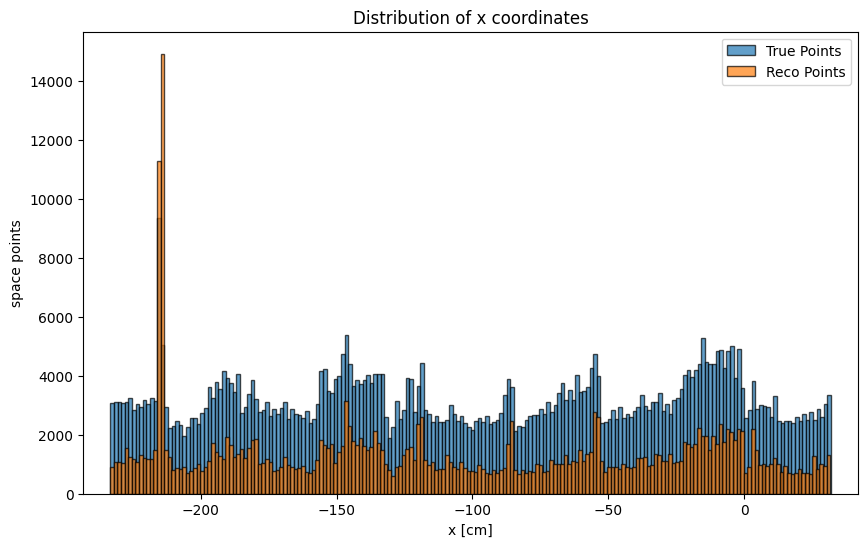

xmin: xmax
true:  -233.2 31.9
reco: -233.25, 31.638


In [9]:
# lets plot x true and reco points
plt.figure(figsize=(10, 6))
plt.hist(all_events_true_x_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_x_points, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_x_points.min() - 10, all_events_true_x_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("x [cm]")
plt.ylabel("space points")
plt.title("Distribution of x coordinates")
plt.legend()
plt.show(block=False)

print("xmin: xmax")
true_x_min = all_events_true_x_points.min()
true_x_max = all_events_true_x_points.max()
reco_x_min = all_events_reco_x_points.min()
reco_x_max = all_events_reco_x_points.max()

print(f"true: ", true_x_min, true_x_max)
print(f"reco: {reco_x_min:2.5g}, {reco_x_max:2.5g}")

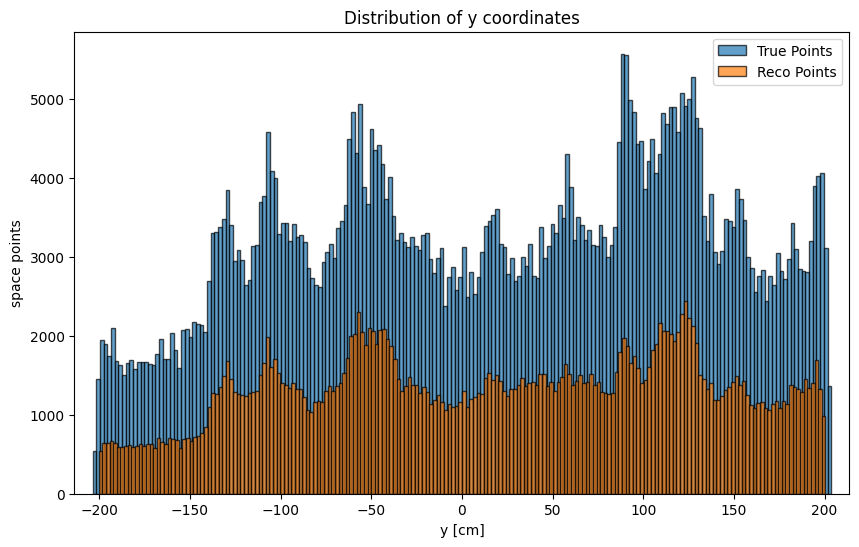

ymin: ymax
true:  -203.7 203.7
reco: -200.31, 200.49


In [10]:
# lets plot y true and reco points
plt.figure(figsize=(10, 6))
plt.hist(all_events_true_y_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_y_points, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_y_points.min() - 10, all_events_true_y_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("y [cm]")
plt.ylabel("space points")
plt.title("Distribution of y coordinates")
plt.legend()
plt.show(block=False)

print("ymin: ymax")
true_y_min = all_events_true_y_points.min()
true_y_max = all_events_true_y_points.max()
reco_y_min = all_events_reco_y_points.min()
reco_y_max = all_events_reco_y_points.max()

print(f"true: ", true_y_min, true_y_max)
print(f"reco: {reco_y_min:2.5g}, {reco_y_max:2.5g}")

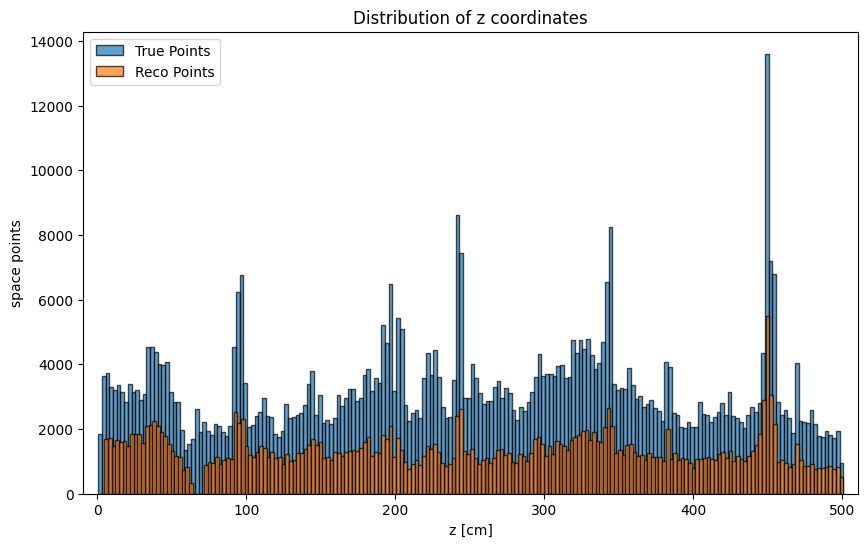

zmin: zmax
true:  0.6 500.6
reco: 4.6997, 500.6


In [11]:
# lets plot y true and reco points

# shift reco z points by 0.5 cm to match true points but make a copy of reco z points to not change original reco z points
all_events_reco_z_points_shifted = all_events_reco_z_points + 0.5

plt.figure(figsize=(10, 6))
plt.hist(all_events_true_z_points, bins=200, edgecolor='black', alpha=0.7, label='True Points')
plt.hist(all_events_reco_z_points_shifted, bins=200, edgecolor='black', alpha=0.7, label='Reco Points')
plt.xlim(all_events_true_z_points.min() - 10, all_events_true_z_points.max() + 10) # Set x-axis range based on true points
#plt.xlim(-300, 300) # Set x-axis range based on true points
plt.xlabel("z [cm]")
plt.ylabel("space points")
plt.title("Distribution of z coordinates")
plt.legend()
plt.show(block=False)

print("zmin: zmax")
true_z_min = all_events_true_z_points.min()
true_z_max = all_events_true_z_points.max()
reco_z_min = all_events_reco_z_points_shifted.min()
reco_z_max = all_events_reco_z_points_shifted.max()

print(f"true: ", true_z_min, true_z_max)
print(f"reco: {reco_z_min:2.5g}, {reco_z_max:2.5g}")